In [2]:
import pandas as pd

df = pd.read_csv("malaysia_house_price_data_2025_cleaned.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2000, 8)


,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,Terrace House,331800.0,304.0,76
1,BANDAR PUTRA,Kulai,Johor,Freehold,"Cluster House, Terrace House",590900.0,322.0,76
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,Terrace House,229954.0,130.0,76
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,Terrace House,255600.0,218.0,76
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,Terrace House,219300.0,168.0,76


In [3]:
# ============================================
# DEFINE FEATURES AND TARGET
# ============================================

X = df[
    [
        'Area',
        'State',
        'Tenure',
        'Type',
        'Median_PSF',
        'Transactions'
    ]
]

y = df['Median_Price']

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']

Target (y):
Median_Price

X shape: (2000, 6)
y shape: (2000,)


In [4]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (1600, 6)
y_train: (1600,)

Testing data:
X_test: (400, 6)
y_test: (400,)


In [5]:
# ============================================
# PREPROCESSING
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical features
categorical_features = [
    'Area',
    'State',
    'Tenure',
    'Type'
]

# Numerical features
numerical_features = [
    'Median_PSF',
    'Transactions'
]

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

print("Preprocessor created successfully.")
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Preprocessor created successfully.
Categorical features: ['Area', 'State', 'Tenure', 'Type']
Numerical features: ['Median_PSF', 'Transactions']


In [6]:
# ============================================
# TEST PREPROCESSING
# ============================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (1600, 6)
Processed X_train shape: (1600, 343)

Original X_test shape: (400, 6)
Processed X_test shape: (400, 343)


In [7]:
# ============================================
# MODEL 1: MULTIPLE LINEAR REGRESSION
# ============================================

from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train the model
linear_model.fit(
    X_train_processed,
    y_train
)

# Make predictions
y_pred_linear = linear_model.predict(
    X_test_processed
)

print("Linear Regression training completed.")
print("Number of predictions:", len(y_pred_linear))

Linear Regression training completed.
Number of predictions: 400


In [8]:
# ============================================
# EVALUATE LINEAR REGRESSION
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("====================================")
print("Linear Regression Results")
print("====================================")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
MAE : 105229.84365036603
MSE : 23776686336.91536
RMSE: 154196.90767624154
R²  : 0.7495018266329143


In [9]:
# ============================================
# MODEL 2: DECISION TREE REGRESSION
# ============================================

from sklearn.tree import DecisionTreeRegressor

# Create the model
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

# Train the model
tree_model.fit(
    X_train_processed,
    y_train
)

# Make predictions
y_pred_tree = tree_model.predict(
    X_test_processed
)

print("Decision Tree Regression training completed.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree Regression training completed.
Number of predictions: 400


In [10]:
# ============================================
# EVALUATE DECISION TREE
# ============================================

mae_tree = mean_absolute_error(
    y_test,
    y_pred_tree
)

mse_tree = mean_squared_error(
    y_test,
    y_pred_tree
)

rmse_tree = np.sqrt(mse_tree)

r2_tree = r2_score(
    y_test,
    y_pred_tree
)

print("====================================")
print("Decision Tree Results")
print("====================================")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Results
MAE : 91761.44672736972
MSE : 21797448511.65275
RMSE: 147639.58991968498
R²  : 0.7703539947131048


In [11]:
# ============================================
# MODEL 3: RANDOM FOREST REGRESSION
# ============================================

from sklearn.ensemble import RandomForestRegressor

# Create the model
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train
)

# Make predictions
y_pred_rf = random_forest_model.predict(
    X_test_processed
)

print("Random Forest Regression training completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest Regression training completed.
Number of predictions: 400


In [12]:
# ============================================
# EVALUATE RANDOM FOREST
# ============================================

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("====================================")
print("Random Forest Results")
print("====================================")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 87673.23655522727
MSE : 18362756554.937504
RMSE: 135509.24896455408
R²  : 0.8065400321215207


In [13]:
# ============================================
# MODEL 4: GRADIENT BOOSTING REGRESSION
# ============================================

from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    loss='squared_error'
)

# Train the model
gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

# Make predictions
y_pred_gb = gradient_boosting_model.predict(
    X_test_processed
)

print("Gradient Boosting Regression training completed.")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting Regression training completed.
Number of predictions: 400


In [14]:
# ============================================
# EVALUATE GRADIENT BOOSTING
# ============================================

mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

print("====================================")
print("Gradient Boosting Results")
print("====================================")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
MAE : 88861.61756663164
MSE : 19352155523.86344
RMSE: 139112.02508720604
R²  : 0.7961162652881068


In [15]:
# ============================================
# CHECK RANDOM FOREST OVERFITTING
# ============================================

y_train_pred_rf = random_forest_model.predict(
    X_train_processed
)

train_r2_rf = r2_score(
    y_train,
    y_train_pred_rf
)

test_r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("====================================")
print("Random Forest R² Comparison")
print("====================================")
print("Training R²:", train_r2_rf)
print("Testing R² :", test_r2_rf)
print("Difference :", train_r2_rf - test_r2_rf)

Random Forest R² Comparison
Training R²: 0.9147953372798412
Testing R² : 0.8065400321215207
Difference : 0.10825530515832049


In [16]:
# ============================================
# TUNED RANDOM FOREST REGRESSION
# ============================================

tuned_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train
tuned_rf_model.fit(
    X_train_processed,
    y_train
)

# Test predictions
y_pred_tuned_rf = tuned_rf_model.predict(
    X_test_processed
)

print("Tuned Random Forest training completed.")

Tuned Random Forest training completed.


In [17]:
# ============================================
# EVALUATE TUNED RANDOM FOREST
# ============================================

mae_tuned_rf = mean_absolute_error(
    y_test,
    y_pred_tuned_rf
)

mse_tuned_rf = mean_squared_error(
    y_test,
    y_pred_tuned_rf
)

rmse_tuned_rf = np.sqrt(mse_tuned_rf)

r2_tuned_rf = r2_score(
    y_test,
    y_pred_tuned_rf
)

print("====================================")
print("Tuned Random Forest Results")
print("====================================")
print("MAE :", mae_tuned_rf)
print("MSE :", mse_tuned_rf)
print("RMSE:", rmse_tuned_rf)
print("R²  :", r2_tuned_rf)

Tuned Random Forest Results
MAE : 93964.04001243298
MSE : 21371802304.193314
RMSE: 146190.97887418812
R²  : 0.7748383705406848


In [18]:
# ============================================
# CHECK TUNED RANDOM FOREST OVERFITTING
# ============================================

y_train_pred_tuned_rf = tuned_rf_model.predict(
    X_train_processed
)

train_r2_tuned_rf = r2_score(
    y_train,
    y_train_pred_tuned_rf
)

print("Training R²:", train_r2_tuned_rf)
print("Testing R² :", r2_tuned_rf)
print("Difference :", train_r2_tuned_rf - r2_tuned_rf)

Training R²: 0.8412833623066471
Testing R² : 0.7748383705406848
Difference : 0.0664449917659623


In [19]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================

import pandas as pd

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Get importance values
importance_values = random_forest_model.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Most Important Features:")
display(feature_importance.head(20))

Top 20 Most Important Features:


,Feature,Importance
341,numerical__Median_PSF,0.679123
325,categorical__Type_Service Residence,0.051096
299,categorical__Type_Apartment,0.047747
314,categorical__Type_Flat,0.041196
342,numerical__Transactions,0.029625
312,categorical__Type_Condominium,0.020899
326,categorical__Type_Terrace House,0.016114
317,categorical__Type_Semi D,0.012497
183,categorical__Area_Petaling Jaya,0.010148
300,categorical__Type_Bungalow,0.008688


In [22]:
# ============================================
# ACTUAL VS PREDICTED VALUES
# ============================================

prediction_results = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_pred_rf
})

# Calculate prediction error
prediction_results['Error'] = (
    prediction_results['Actual_Price']
    - prediction_results['Predicted_Price']
)

# Absolute error
prediction_results['Absolute_Error'] = (
    prediction_results['Error'].abs()
)

print("Prediction Results:")
display(prediction_results.head(10))

print("Average Error:",
      prediction_results['Error'].mean())

print("Average Absolute Error:",
      prediction_results['Absolute_Error'].mean())

print("Largest Absolute Error:",
      prediction_results['Absolute_Error'].max())

Prediction Results:


,Actual_Price,Predicted_Price,Error,Absolute_Error
0,165000.0,1.460064e+05,18993.582167,18993.582167
1,380000.0,2.979670e+05,82032.967097,82032.967097
2,1484150.0,1.159812e+06,324338.219899,324338.219899
3,550000.0,4.216675e+05,128332.479096,128332.479096
4,700000.0,5.346059e+05,165394.050176,165394.050176
5,592500.0,3.175556e+05,274944.374179,274944.374179
6,599800.0,6.242064e+05,-24406.378514,24406.378514
7,289000.0,2.956939e+05,-6693.857374,6693.857374
8,640000.0,7.944507e+05,-154450.745173,154450.745173
9,378000.0,6.502291e+05,-272229.065344,272229.065344


Average Error: 186.4962831464698
Average Absolute Error: 87673.23655522727
Largest Absolute Error: 721891.7018396694


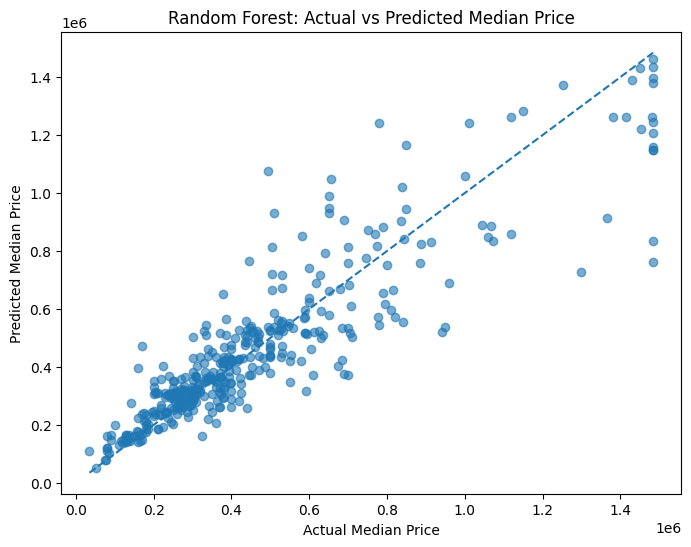

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("Random Forest: Actual vs Predicted Median Price")

plt.show()

In [24]:
import joblib

# ============================================
# SAVE ALL FOUR MODELS
# ============================================

model_bundle = {
    'preprocessor': preprocessor,

    'models': {
        'Linear Regression': linear_model,
        'Decision Tree': tree_model,
        'Random Forest': random_forest_model,
        'Gradient Boosting': gradient_boosting_model
    },

    'metrics': {
        'Linear Regression': {
            'MAE': mae_linear,
            'MSE': mse_linear,
            'RMSE': rmse_linear,
            'R2': r2_linear
        },

        'Decision Tree': {
            'MAE': mae_tree,
            'MSE': mse_tree,
            'RMSE': rmse_tree,
            'R2': r2_tree
        },

        'Random Forest': {
            'MAE': mae_rf,
            'MSE': mse_rf,
            'RMSE': rmse_rf,
            'R2': r2_rf
        },

        'Gradient Boosting': {
            'MAE': mae_gb,
            'MSE': mse_gb,
            'RMSE': rmse_gb,
            'R2': r2_gb
        }
    }
}

joblib.dump(
    model_bundle,
    'malaysia_house_price_models.joblib'
)

print("====================================")
print("ALL MODELS SAVED SUCCESSFULLY")
print("====================================")
print("File: malaysia_house_price_models.joblib")
print("Models saved:")

for model_name in model_bundle['models']:
    print("-", model_name)

ALL MODELS SAVED SUCCESSFULLY
File: malaysia_house_price_models.joblib
Models saved:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [25]:
# ============================================
# VERIFY SAVED MODEL BUNDLE
# ============================================

loaded_bundle = joblib.load(
    'malaysia_house_price_models.joblib'
)

print("Model bundle loaded successfully!")

print("\nAvailable models:")

for model_name in loaded_bundle['models']:
    print("-", model_name)

print("\nStored metrics:")
print(
    pd.DataFrame(loaded_bundle['metrics']).T
)

Model bundle loaded successfully!

Available models:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Stored metrics:
                             MAE           MSE           RMSE        R2
Linear Regression  105229.843650  2.377669e+10  154196.907676  0.749502
Decision Tree       91761.446727  2.179745e+10  147639.589920  0.770354
Random Forest       87673.236555  1.836276e+10  135509.248965  0.806540
Gradient Boosting   88861.617567  1.935216e+10  139112.025087  0.796116
